# IMPORT LIBRARIES

In [1]:
import dtale
import jdatetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import geopandas as gpd
import sys
from sklearn.model_selection import train_test_split
PROJECT_ROOT = Path.cwd().parent
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.style import set_plot_style, COLORS, fa
from src.utils.plot_utils import save_figure
from src.utils.statistics import (
    normalize_year,
    normalize_integer,
    missing_by_group,
    hierarchical_impute,
)

set_plot_style()

In [2]:
# Loading Data
DATA_PATH = "divar.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

# EDA WITH DTALE

In [3]:
dtale.show(df)

# DATA CLEANING

In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
# construction_year
df_construction_year = df.copy()
df_construction_year["construction_year"] = (
    df_construction_year["construction_year"].apply(normalize_year).astype("Int16")
)
df = df_construction_year

In [6]:
# rooms_count
df_rooms_count = df.copy()
df_rooms_count["rooms_count"] = pd.Categorical(
    df_rooms_count["rooms_count"],
    categories=["بدون اتاق", "یک", "دو", "سه", "چهار", "پنج یا بیشتر"],
    ordered=True,
)
mapping = {"بدون اتاق": 0, "یک": 1, "دو": 2, "سه": 3, "چهار": 4, "پنج یا بیشتر": 5}

df_rooms_count["rooms_count"] = (
    df_rooms_count["rooms_count"].map(mapping).astype("Int8")
)
df = df_rooms_count

In [7]:
# total_floors_count
df_total_floors_count = df.copy()
df_total_floors_count["total_floors_count"] = (
    df_total_floors_count["total_floors_count"]
    .apply(lambda x: normalize_integer(x, {"30+": 31, "unselect": pd.NA}))
    .astype("Int8")
)
df = df_total_floors_count

In [8]:
# unit_per_floor
df_unit_per_floor = df.copy()
df_unit_per_floor["unit_per_floor"] = (
    df_unit_per_floor["unit_per_floor"]
    .apply(lambda x: normalize_integer(x, {"more_than_8": 9, "unselect": pd.NA}))
    .astype("Int8")
)
df = df_unit_per_floor

In [9]:
# bool_cols
df_bool_cols = df.copy()
bool_cols = [
    "rent_to_single",
    "rent_credit_transform",
    "transformable_price",
    "has_business_deed",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "is_rebuilt",
    "has_water",
    "has_electricity",
    "has_gas",
    "has_security_guard",
    "has_barbecue",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
]

df_bool_cols[bool_cols] = df_bool_cols[bool_cols].astype("boolean")
df_bool_cols["has_balcony"] = (
    df_bool_cols["has_balcony"]
    .str.strip()
    .str.lower()
    .replace(
        {
            "true": True,
            "false": False,
            "unselect": pd.NA,
        }
    )
    .astype("boolean")
)
df = df_bool_cols

In [10]:
float_cols = [
    "rent_value",
    "price_value",
    "credit_value",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",
    "land_size",
    "building_size",
    "regular_person_capacity",
    "cost_per_extra_person",
    "rent_price_on_regular_days",
    "rent_price_on_special_days",
    "rent_price_at_weekends",
    "location_latitude",
    "location_longitude",
    "location_radius",
]
df[float_cols] = df[float_cols].astype("float32")

In [11]:
# floor
df_floor = df.copy()
df_floor["floor"] = (
    df_floor["floor"].apply(lambda x: normalize_integer(x, {"30+": 31})).astype("Int8")
)
df = df_floor

In [12]:
# created_at_month
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

In [13]:
# category_cols
df_category = df.copy()
category_with_unselect = [
    "deed_type",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
]
for col in category_with_unselect:
    df_category[col] = df_category[col].replace("unselect", pd.NA)

category_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "user_type",
    "rent_mode",
    "rent_type",
    "price_mode",
    "credit_mode",
    "deed_type",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
    "property_type",
]
df_category[category_cols] = df_category[category_cols].astype("category")
df = df_category

In [14]:
# location_latitude and location_longitude
iran = gpd.read_file("../data/maps/iran_provinces.geojson")
iran_polygon = iran.union_all()
location_df = df[
    df["location_latitude"].notna() & df["location_longitude"].notna()
].copy()
location_gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(
        location_df["location_longitude"], location_df["location_latitude"]
    ),
    crs="EPSG:4326",
)
iran_gdf = gpd.GeoDataFrame(geometry=[iran_polygon], crs="EPSG:4326")
inside = gpd.sjoin(location_gdf, iran_gdf, predicate="intersects", how="inner")
inside_index = inside.index
df = pd.concat([df[df["location_latitude"].isna()], df.loc[inside_index]]).sort_index()

In [15]:
# building_size
df.loc[df["building_size"] > 10_000, "building_size"] = pd.NA # we have to remove them !!!

df["building_size"] = df.groupby("cat3_slug")["building_size"].transform(
    lambda s: s.fillna(s.median())
)

/tmp/ipykernel_3312/4090935286.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [16]:
# land_size
df.loc[df["land_size"] > 10_000, "land_size"] = pd.NA # we have to remove them !!!

df["land_size"] = df.groupby("cat3_slug")["land_size"].transform(
    lambda s: s.fillna(s.median())
)

/tmp/ipykernel_3312/663603082.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [17]:
q1 = df["price_value"].quantile(0.01)
q99 = df["price_value"].quantile(0.99)
df = df[df["price_value"].between(q1, q99)]

----

# SPLITTING DATA TO ONLY SELL

In [18]:
df_sell = df[(df["cat2_slug"].isin(["residential-sell","commercial-sell"]))].copy()

# FEATURE ENGINEERING

In [19]:
df_sell["created_year"] = (
    df_sell["created_at_month"]
    .apply(lambda d: jdatetime.date.fromgregorian(date=d.date()).year)
    .astype("Int16")
)
df_sell["created_month"] = (
    df_sell["created_at_month"]
    .apply(lambda d: jdatetime.date.fromgregorian(date=d.date()).month)
    .astype("Int8")
)

df_sell["building_age"] = (
    df_sell["created_year"] - df_sell["construction_year"]
).astype("Int16")

In [20]:
df_sell["created_month"] = df_sell["created_month"].astype("category")

In [21]:
features = [
    "price_value",
    "has_balcony",
    "is_rebuilt",
    "has_elevator",
    "location_longitude",
    "location_latitude",
    "has_parking",
    "has_warehouse",
    "cat3_slug",
    "building_age",
    "created_month",
    "created_year",
    "rooms_count",
    "floor",
    "building_size",
    "cat2_slug",
    "city_slug",
    "total_floors_count",
    "unit_per_floor",
]
df_sell = df_sell[features]

In [23]:
df_sell.drop_duplicates(inplace=True)

In [24]:
df_sell.info()

<class 'pandas.core.frame.DataFrame'>
Index: 553566 entries, 1 to 999997
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   price_value         553566 non-null  float32 
 1   has_balcony         309339 non-null  boolean 
 2   is_rebuilt          309179 non-null  boolean 
 3   has_elevator        303191 non-null  boolean 
 4   location_longitude  363199 non-null  float32 
 5   location_latitude   363199 non-null  float32 
 6   has_parking         420520 non-null  boolean 
 7   has_warehouse       420520 non-null  boolean 
 8   cat3_slug           553566 non-null  category
 9   building_age        446418 non-null  Int16   
 10  created_month       553566 non-null  category
 11  created_year        553566 non-null  Int16   
 12  rooms_count         446471 non-null  Int8    
 13  floor               303191 non-null  Int8    
 14  building_size       553566 non-null  float32 
 15  cat2_slug           55

In [25]:
numeric_cols = [
    "price_value",
    "building_size",
    "building_age",
    "created_year",
    "rooms_count",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "location_latitude",
    "location_longitude",
]

corr = df_sell[numeric_cols].corr(numeric_only=True)

print(corr["price_value"].sort_values(ascending=False))

price_value           1.000000
rooms_count           0.332315
floor                 0.139248
total_floors_count    0.132927
building_size         0.075082
location_latitude     0.029323
building_age          0.020524
location_longitude   -0.002007
created_year         -0.003126
unit_per_floor       -0.098502
Name: price_value, dtype: float64


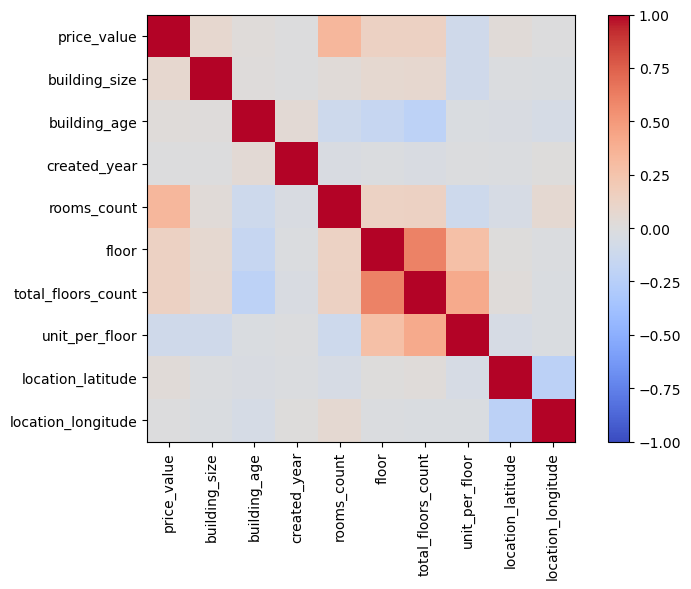

In [26]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

# OUTLIERS

In [28]:
df_sell.describe()

,price_value,location_longitude,location_latitude,building_age,created_year,rooms_count,floor,building_size,total_floors_count,unit_per_floor
count,5.535660e+05,363199.000000,363199.000000,446418.0,553566.0,446471.0,303191.0,553566.000000,184711.0,182500.0
mean,5.363460e+09,51.551529,35.088165,8.659749,1402.992613,1.990575,2.876421,240.108704,4.971496,2.348455
std,8.213791e+09,3.106677,2.303602,8.469149,0.086843,0.920742,2.436295,651.203552,2.842885,1.461641
min,3.500000e+03,44.147614,25.144274,-1.0,1399.0,0.0,-1.0,1.000000,2.0,1.0
25%,1.450000e+09,50.563980,34.765232,1.0,1403.0,2.0,1.0,78.000000,4.0,1.0
50%,2.850000e+09,51.327255,35.725693,7.0,1403.0,2.0,2.0,110.000000,4.0,2.0
75%,5.800000e+09,51.835014,36.354530,13.0,1403.0,2.0,4.0,180.000000,5.0,3.0
max,8.500000e+10,62.707977,39.681236,33.0,1403.0,5.0,31.0,10000.000000,31.0,9.0


In [29]:
invalid_prices = [
    111111e+08,
    9999999999,
    123456789,
111111111.00,
11111111.00,
1111111111.00]

df_sell = df_sell[~df_sell["price_value"].isin(invalid_prices)]
df_sell = df_sell[(df_sell["price_value"]>1e7)&(df_sell["price_value"]<1e10)]
df_sell = df_sell[(df_sell["building_size"]>50)&(df_sell["building_size"]<5000)]

In [30]:
df_sell.info()

<class 'pandas.core.frame.DataFrame'>
Index: 434074 entries, 1 to 999997
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   price_value         434074 non-null  float32 
 1   has_balcony         246423 non-null  boolean 
 2   is_rebuilt          247414 non-null  boolean 
 3   has_elevator        239717 non-null  boolean 
 4   location_longitude  284171 non-null  float32 
 5   location_latitude   284171 non-null  float32 
 6   has_parking         333318 non-null  boolean 
 7   has_warehouse       333318 non-null  boolean 
 8   cat3_slug           434074 non-null  category
 9   building_age        341108 non-null  Int16   
 10  created_month       434074 non-null  category
 11  created_year        434074 non-null  Int16   
 12  rooms_count         341146 non-null  Int8    
 13  floor               239717 non-null  Int8    
 14  building_size       434074 non-null  float32 
 15  cat2_slug           43

# MODELING

In [31]:
# features = [
#     "building_size",
#     "rooms_count",
#     "floor",
#     "total_floors_count",
#     "unit_per_floor",
#     "location_latitude",
#     "location_longitude",
#     "city_slug",
#     "cat2_slug",
#     "cat3_slug",
#     "has_parking",
#     "has_elevator",
#     "has_warehouse",
#     "has_balcony",
#     "is_rebuilt",
# ]
features = [
    # "price_value",
    "has_balcony",
    "is_rebuilt",
    "has_elevator",
    "location_longitude",
    "location_latitude",
    "has_parking",
    "has_warehouse",
    "cat3_slug",
    "building_age",
    "created_month",
    "created_year",
    "rooms_count",
    "floor",
    "building_size",
    "cat2_slug",
    "city_slug",
    "total_floors_count",
    "unit_per_floor",
]

In [32]:
data = df_sell[features + ["price_value"]].dropna().copy()

In [33]:
X = pd.get_dummies(
    data[features],
    columns=["city_slug", "created_month", "cat2_slug", "cat3_slug"],
    drop_first=True,
    dtype=int,
)

y = np.log1p(data["price_value"])

In [34]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42)

## SIMPLE LINEAR REGRESSION FOR TESTING

In [41]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [42]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test,pred)
rmse = np.sqrt(mean_squared_error(y_test,pred))
r2 = r2_score(y_test,pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.3052128121910543
RMSE: 0.48188247381827926
R2: 0.5043308559572286


## CATBOOST REGRESSOR
###### BEST TUNING AFTER 30 ATTEMPTS

In [37]:
model = CatBoostRegressor(
    iterations=6000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=200)
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    verbose=200)

0:	learn: 0.6873895	test: 0.6725798	best: 0.6725798 (0)	total: 73.5ms	remaining: 7m 21s


200:	learn: 0.4536903	test: 0.4379097	best: 0.4379097 (200)	total: 1.45s	remaining: 41.9s


400:	learn: 0.4395773	test: 0.4260866	best: 0.4260866 (400)	total: 2.91s	remaining: 40.7s


600:	learn: 0.4312227	test: 0.4201679	best: 0.4201679 (600)	total: 4.35s	remaining: 39.1s


800:	learn: 0.4239474	test: 0.4155003	best: 0.4155003 (800)	total: 5.75s	remaining: 37.3s


...

5400:	learn: 0.3671398	test: 0.3975815	best: 0.3975815 (5400)	total: 37s	remaining: 4.1s


5600:	learn: 0.3656886	test: 0.3973199	best: 0.3973108 (5559)	total: 38.4s	remaining: 2.73s


5800:	learn: 0.3643929	test: 0.3971028	best: 0.3971009 (5797)	total: 39.8s	remaining: 1.37s


5999:	learn: 0.3629315	test: 0.3969724	best: 0.3969663 (5997)	total: 41.2s	remaining: 0us

bestTest = 0.3969662658
bestIteration = 5997

Shrink model to first 5998 iterations.


CatBoostRegressor(bagging_temperature=1, depth=6, early_stopping_rounds=200, eval_metric='RMSE', iterations=6000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, random_strength=1)

In [38]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test,pred)
rmse = np.sqrt(mean_squared_error(y_test,pred))
r2 = r2_score(y_test,pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.2106650389136761
RMSE: 0.4008829666482118
R2: 0.6569599481321976


---

## XGBOOST REGRESSOR (FINAL MODEL)
###### BEST TUNING AFTER 15 ATTEMPTS

In [40]:
model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False)
pred = model.predict(X_test)
mae = mean_absolute_error(y_test,pred)
rmse = np.sqrt(mean_squared_error(y_test,pred))
r2 = r2_score(y_test,pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.2055913507938385
RMSE: 0.39642829686355413
R2: 0.6645414233207703


# CONCLUSION :
### Model Selection

### During the data exploration phase, it became clear that the dataset suffered from structural missingness. Many features contained missing values because users were not required to provide all property information when publishing advertisements. In addition, the dataset contained a large number of missing and invalid values due to inconsistent user input, making data preprocessing one of the most challenging parts of this project.

### After exploring the dataset and studying different machine learning algorithms, I found that tree-based models are generally well suited for structured tabular datasets like this one. Unlike linear models, they do not require feature scaling and are generally more robust to outliers. They are also capable of capturing complex non-linear relationships between the input features and the target variable. Since the dataset contained many categorical features that were encoded during preprocessing, tree-based models were considered an appropriate choice.

### To evaluate different approaches, I implemented and compared Linear Regression, CatBoost Regressor, and XGBoost Regressor. Linear Regression was used as a baseline model because of its simplicity and ease of interpretation. However, due to the complexity of the relationships in the housing market data, its performance was limited.

### Finally, after several experiments and hyperparameter tuning, XGBoost Regressor achieved the best overall performance among the evaluated models. The models were evaluated using MAE, RMSE, R², and Adjusted R². Although the performance difference between XGBoost Regressor and CatBoost Regressor was very small, XGBoost Regressor performed slightly better and achieved the highest R² score of approximately 0.66. Therefore, it was selected as the final model for this project.